In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker

In [2]:
PATH = "data/tennis/"
tennis = pd.read_csv(PATH+"atp_tennis.csv")
prize = pd.read_csv(PATH + "Mens_Tennis_Grand_Slam_Winner.csv")

prize.head()

,YEAR,TOURNAMENT,WINNER,RUNNER-UP,WINNER_NATIONALITY,WINNER_ATP_RANKING,RUNNER-UP_ATP_RANKING,WINNER_LEFT_OR_RIGHT_HANDED,TOURNAMENT_SURFACE,WINNER_PRIZE
0,2023,Australian Open,Novak Djokovic,Stefanos Tsitsipas,Serbian,1.0,3.0,right,Plexicushion Prestige,2050000.0
1,2022,U.S. Open,Carlos Alcaraz,Casper Rudd,Spanish,2.0,5.0,right,DecoTurf - outdoors,2600000.0
2,2022,Wimbledon,Novak Djokovic,Nick Kyrgios,Serbian,NaN,25.0,right,Grass / Outdoor,2507460.0
3,2022,French Open,Rafael Nadal,Casper Rudd,Spanish,5.0,8.0,left,Clay,1870000.0
4,2022,Australian Open,Rafael Nadal,Daniil Medvedev,Spanish,5.0,2.0,left,Plexicushion Prestige,4400000.0


In [3]:
tennis.head()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,-1,-1,-1.0,-1.0,6-3 6-7 4-6
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,-1,-1,-1.0,-1.0,4-6 6-7
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.0,-1.0,3-6 3-6
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.0,-1.0,6-4 6-2
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,-1,-1,-1.0,-1.0,4-6 4-6


In [4]:
# List of tournaments in prizes dataset
prize_tourn = prize["TOURNAMENT"].unique()
print(prize_tourn)

<StringArray>
[      'Australian Open',             'U.S. Open',             'Wimbledon',
           'French Open', 'Australian Open (Dec)', 'Australian Open (Jan)']
Length: 6, dtype: str


In [5]:
# Cleaning the data 

tennis_tourn = tennis["Tournament"].unique()
prize["Tournament"] = prize["TOURNAMENT"].replace(r"\s*\(.*?\)", "", regex=True)
awards = prize[['Tournament', 'YEAR', 'WINNER_PRIZE']]
awards['Year'] = awards['YEAR']
tennis['Date'] = pd.to_datetime(tennis["Date"])
tennis["Year"] = tennis['Date'].dt.year
print(prize['Tournament'].unique())


<StringArray>
['Australian Open', 'U.S. Open', 'Wimbledon', 'French Open']
Length: 4, dtype: str


In [6]:
tennis_clean = tennis[tennis['Tournament'].isin(awards['Tournament'])].reset_index()
tennis_clean = tennis_clean[['Tournament', 'Series', 'Year', 'Round', 'Score']]
tennis_clean['Sets'] = tennis_clean['Score'].str.split().str.len()
tennis_clean.head()

,Tournament,Series,Year,Round,Score,Sets
0,Australian Open,Grand Slam,2000,1st Round,6-4 7-6 7-5,3
1,Australian Open,Grand Slam,2000,1st Round,3-6 6-7 2-6,3
2,Australian Open,Grand Slam,2000,1st Round,6-2 4-6 6-7 6-3 6-0,5
3,Australian Open,Grand Slam,2000,1st Round,0-6 2-6 2-6,3
4,Australian Open,Grand Slam,2000,1st Round,7-5 7-6 4-6 2-6 6-8,5


The hypothesis we are trying to prove is there a correlation between the effort players are putting to win measured by the number of sets for each game as the monetary rewards increases and what would be the correlation over the years. 

In [7]:
avg = tennis_clean.groupby(['Tournament', 'Year', 'Series'])['Sets'].mean().round(2).to_frame().reset_index()
combined = avg.merge(awards, how='left', on=['Tournament', 'Year'])
combined = combined.dropna(axis=0)
combined = combined.drop(columns=['YEAR'])
combined

,Tournament,Year,Series,Sets,WINNER_PRIZE
0,Australian Open,2000,Grand Slam,3.70,755000.0
1,Australian Open,2001,Grand Slam,3.74,830500.0
2,Australian Open,2002,Grand Slam,3.81,1000000.0
3,Australian Open,2003,Grand Slam,3.80,1127850.0
4,Australian Open,2004,Grand Slam,3.64,1200000.0
...,...,...,...,...,...
71,Wimbledon,2017,Grand Slam,3.68,2200000.0
72,Wimbledon,2018,Grand Slam,3.73,2250000.0
73,Wimbledon,2019,Grand Slam,3.64,2350000.0
74,Wimbledon,2021,Grand Slam,3.76,1700000.0


In [8]:

austr_open = combined[combined['Tournament']=='Australian Open']
austr_open

,Tournament,Year,Series,Sets,WINNER_PRIZE
0,Australian Open,2000,Grand Slam,3.70,755000.0
1,Australian Open,2001,Grand Slam,3.74,830500.0
2,Australian Open,2002,Grand Slam,3.81,1000000.0
3,Australian Open,2003,Grand Slam,3.80,1127850.0
4,Australian Open,2004,Grand Slam,3.64,1200000.0
5,Australian Open,2005,Grand Slam,3.66,1206620.0
6,Australian Open,2006,Grand Slam,3.78,1220000.0
7,Australian Open,2007,Grand Slam,3.68,1281000.0
8,Australian Open,2008,Grand Slam,3.61,1370000.0
9,Australian Open,2009,Grand Slam,3.66,2000000.0


In [9]:
# Focus only on the finals 
finals = tennis_clean[tennis_clean['Round']=='The Final']
finals_comb = finals.merge(awards, how='left', on=['Tournament', 'Year'])
finals_comb = finals_comb.dropna(axis=0)
finals_comb = finals_comb.drop(columns=['YEAR', 'Score', 'Series', 'Round'])
finals_comb['Prize'] = finals_comb['WINNER_PRIZE'].astype(float)
finals_comb = finals_comb.drop(columns=['WINNER_PRIZE'])

In [10]:
finals_comb

,Tournament,Year,Sets,Prize
0,Australian Open,2000,4,755000.0
1,French Open,2000,4,4240000.0
2,Wimbledon,2000,4,477500.0
3,Australian Open,2001,3,830500.0
4,French Open,2001,4,4538000.0
...,...,...,...,...
64,Wimbledon,2021,4,1700000.0
65,Australian Open,2022,5,4400000.0
66,French Open,2022,3,1870000.0
67,Wimbledon,2022,4,2507460.0


In [11]:
austr_finals = finals_comb[finals_comb['Tournament']== 'Australian Open']
austr_finals

,Tournament,Year,Sets,Prize
0,Australian Open,2000,4,755000.0
3,Australian Open,2001,3,830500.0
6,Australian Open,2002,4,1000000.0
9,Australian Open,2003,3,1127850.0
12,Australian Open,2004,3,1200000.0
15,Australian Open,2005,4,1206620.0
18,Australian Open,2006,4,1220000.0
21,Australian Open,2007,3,1281000.0
24,Australian Open,2008,4,1370000.0
27,Australian Open,2009,5,2000000.0


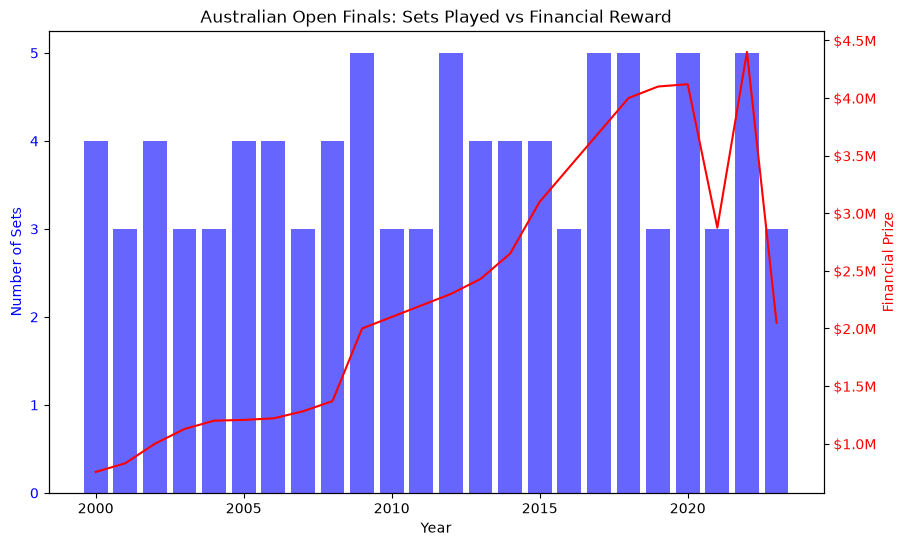

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(austr_finals['Year'], austr_finals['Sets'], color='blue', alpha=0.6, label='Number of sets in the final')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Sets', color = 'blue')
ax.tick_params(axis='y', labelcolor='blue')

ax2 = ax.twinx()
line = ax2.plot(austr_finals['Year'], austr_finals['Prize'], color='red', label='Winner Financial Reward')
ax2.set_ylabel('Financial Prize', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'${x*1e-6:.1f}M'))

plt.title('Australian Open Finals: Sets Played vs Financial Reward')
plt.show()

In [20]:
all_finals = tennis_clean[tennis_clean['Round']=='The Final']
all_finals = all_finals.drop(columns=['Round', 'Score', 'Series'])
all_finals_combined = all_finals.merge(awards, how='left', on=['Tournament', 'Year'])
all_finals_combined = all_finals_combined.dropna(axis=0)
all_finals_combined['Prize'] = all_finals_combined['WINNER_PRIZE'].astype(float)
all_finals_combined = all_finals_combined.drop(columns=['WINNER_PRIZE', 'YEAR'])
all_finals_combined

,Tournament,Year,Sets,Prize
0,Australian Open,2000,4,755000.0
1,French Open,2000,4,4240000.0
2,Wimbledon,2000,4,477500.0
3,Australian Open,2001,3,830500.0
4,French Open,2001,4,4538000.0
...,...,...,...,...
64,Wimbledon,2021,4,1700000.0
65,Australian Open,2022,5,4400000.0
66,French Open,2022,3,1870000.0
67,Wimbledon,2022,4,2507460.0


In [31]:
avg_perf = all_finals_combined.groupby('Year')[['Sets', 'Prize']].mean().reset_index()
avg_perf['Prize'] = avg_perf['Prize'].round(1)
avg_perf

,Year,Sets,Prize
0,2000,4.000000,1824166.7
1,2001,4.000000,1956166.7
2,2002,3.666667,768333.3
3,2003,3.000000,847616.7
4,2004,4.000000,887500.0
5,2005,3.666667,905540.0
6,2006,4.000000,938333.3
7,2007,4.000000,993666.7
8,2008,4.000000,1040000.0
9,2009,4.333333,1303333.3


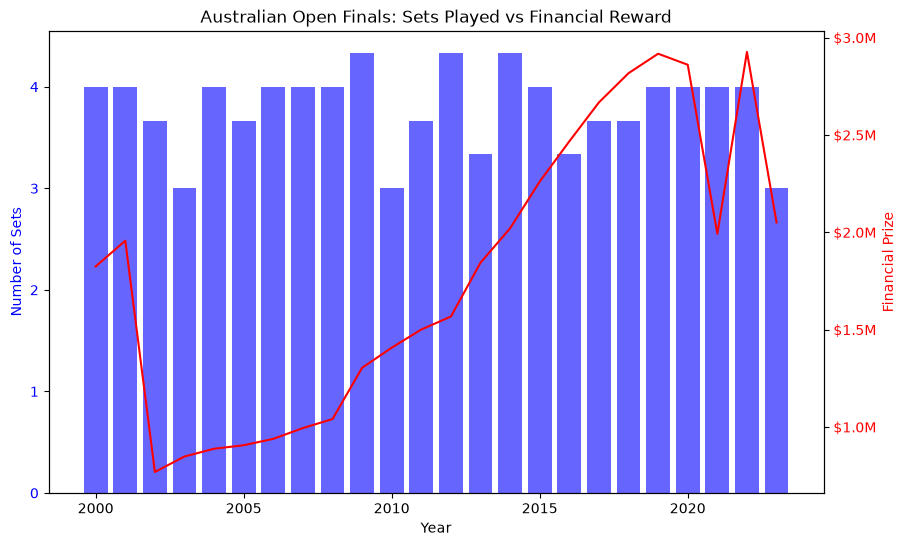

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(avg_perf['Year'], avg_perf['Sets'], color='blue', alpha=0.6, label='Number of sets in the final')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Sets', color = 'blue')
ax.tick_params(axis='y', labelcolor='blue')

ax2 = ax.twinx()
line = ax2.plot(avg_perf['Year'], avg_perf['Prize'], color='red', label='Winner Financial Reward')
ax2.set_ylabel('Financial Prize', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'${x*1e-6:.1f}M'))

plt.title('Australian Open Finals: Sets Played vs Financial Reward')
plt.show()